### 1. Imports

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

### 2. Load data set

In [6]:
df = pd.read_csv('data/bioactivity_data_3class_pIC50_pubchem_fp.csv')
df = df.drop('Unnamed: 0', axis=1)
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.301030
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.568636
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.744727
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.958607
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.399027
1620,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.275724
1621,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.962574
1622,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.389340


In [7]:
X = df.drop('pIC50', axis=1)
y = df.pIC50

### 3. Data pre-processing

In [8]:
# Examine X dimension
X.shape

(1624, 881)

In [10]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(0.8 * (1 - 0.8)))
X = selection.fit_transform(X)
X.shape

(1624, 169)

In [11]:
# Perform data splitting using 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### 4. Compare ML algorithms

In [32]:
# Define and build lazyclassifier
clf = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None, predictions=True)
models_train, predictions_train = clf.fit(X_train, X_train, y_train, y_train)
models_test, predictions_test = clf.fit(X_train, X_test, y_train, y_test)

In [35]:
# Performance table of the training set (80% subset)
models_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
DecisionTreeRegressor,0.922862,0.932906,0.353771,0.023020
ExtraTreeRegressor,0.922862,0.932906,0.353771,0.022168
ExtraTreesRegressor,0.922862,0.932906,0.353771,1.424649
GaussianProcessRegressor,0.922862,0.932906,0.353771,0.286709
MLPRegressor,0.901424,0.914259,0.399921,1.522750
RandomForestRegressor,0.897831,0.911133,0.407146,0.907405
BaggingRegressor,0.884721,0.899731,0.432478,0.115767
HistGradientBoostingRegressor,0.870666,0.887506,0.458084,1.351278
SVR,0.781904,0.810301,0.594857,0.266115


In [36]:
# Performance table of the test set (20% subset)
models_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
RandomForestRegressor,6.489181e-01,8.320442e-01,5.576256e-01,0.914546
HistGradientBoostingRegressor,6.370978e-01,8.263894e-01,5.669351e-01,1.180103
BaggingRegressor,6.082892e-01,8.126075e-01,5.890081e-01,0.100523
MLPRegressor,5.906401e-01,8.041642e-01,6.021313e-01,1.496869
KNeighborsRegressor,5.742511e-01,7.963239e-01,6.140663e-01,0.009363
ExtraTreesRegressor,5.710555e-01,7.947951e-01,6.163666e-01,1.224147
SVR,5.697985e-01,7.941937e-01,6.172690e-01,0.170130
NuSVR,5.672202e-01,7.929603e-01,6.191160e-01,0.149043
ExtraTreeRegressor,5.220507e-01,7.713514e-01,6.506230e-01,0.020564


### 5. Visualize model performance

[(0.0, 1.0)]

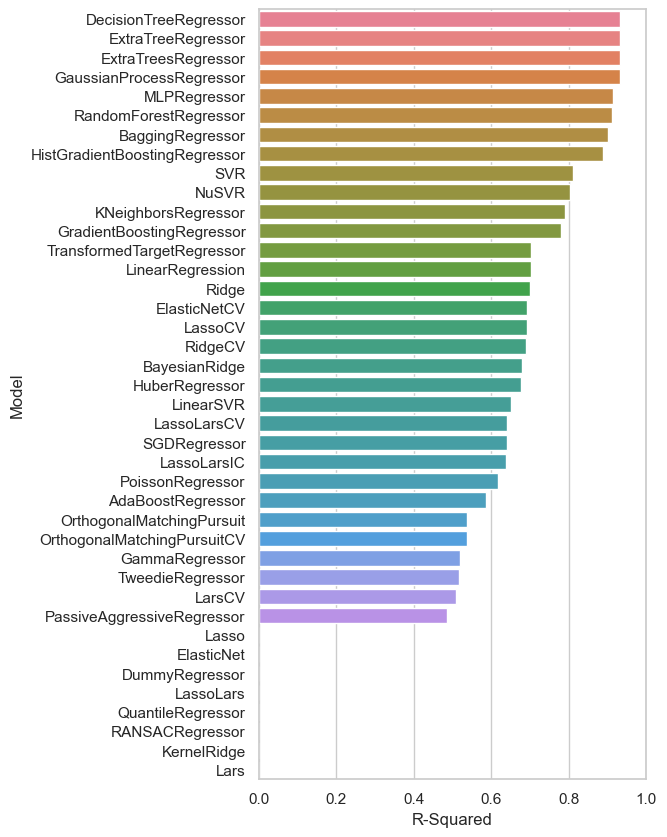

In [43]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt

plt.figure(figsize=(5,10))
sns.set_theme(style='whitegrid')
ax = sns.barplot(y=models_train.index, x='R-Squared', data=models_train, hue=models_train.index)
ax.set(xlim=(0,1))


[(0.0, 8.0)]

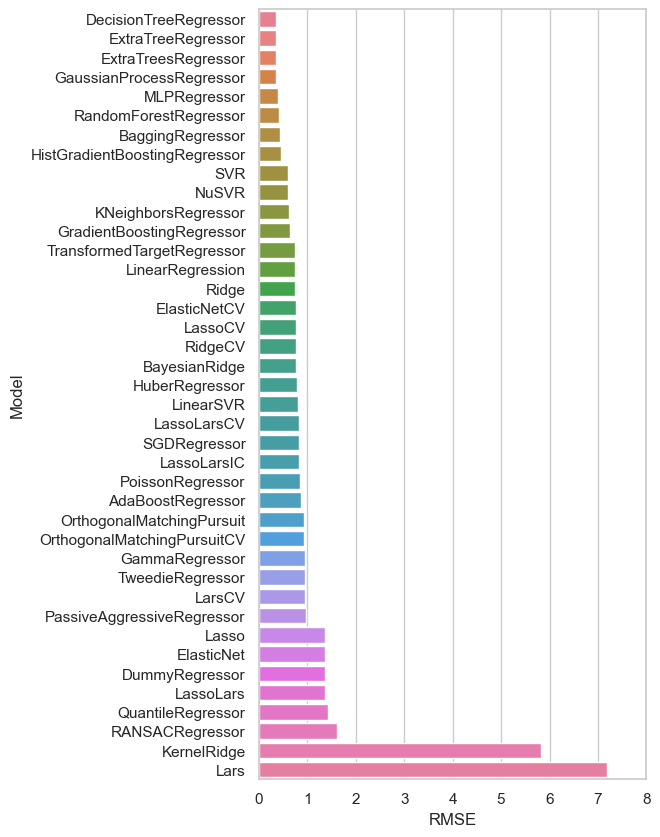

In [47]:
# Bar plot of RMSE values

plt.figure(figsize=(5,10))
sns.set_theme(style='whitegrid')
ax = sns.barplot(y=models_train.index, x="RMSE", data=models_train, hue=models_train.index)
ax.set(xlim=(0,8))

[(0.0, 2.0)]

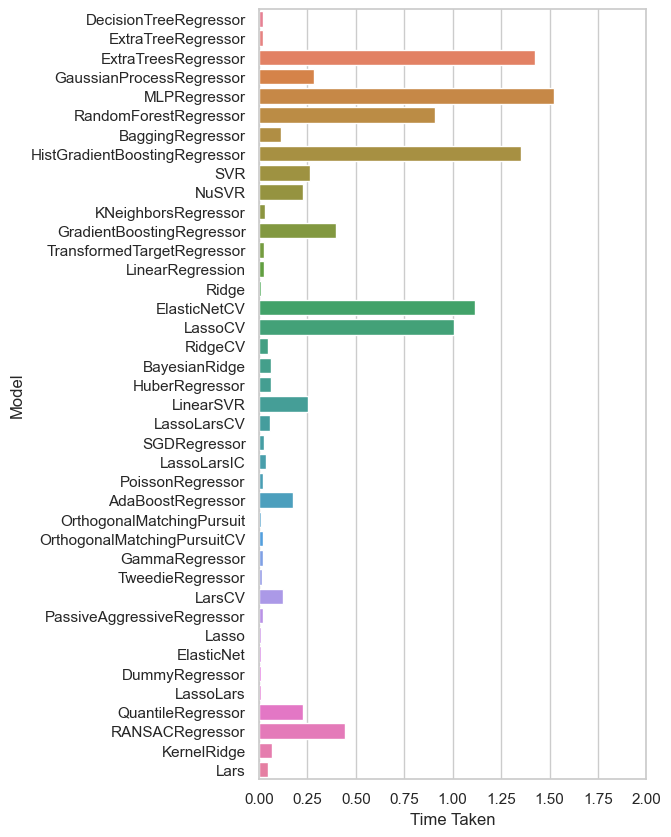

In [48]:
# Bar plot of calculation time
plt.figure(figsize=(5,10))
sns.set_theme(style='whitegrid')
ax = sns.barplot(y=models_train.index, x="Time Taken", data=models_train, hue=models_train.index)
ax.set(xlim=(0,2))